# 🌳 Decision Tree Algorithms — Complete Guide
### Classification & Regression with Python

---

## 📚 Table of Contents
1. [Why Tree-Based Algorithms?](#why)
2. [Types of Tree-Based Algorithms](#types)
3. [How a Decision Tree Works](#how)
4. [Decision Tree for Classification](#classification)
   - Gini Index
   - Entropy & Information Gain
   - Weighted Gini Calculation
5. [Decision Tree for Regression](#regression)
   - MSE-based splitting
6. [sklearn Implementation](#sklearn)
7. [Visualization](#viz)
8. [Overfitting & Hyperparameter Tuning](#tuning)


---
## Part 1. Why Tree-Based Algorithms? <a id='why'></a>

In real-world problems, the **relationship between features and the target is rarely linear**.

For example:
- A person's loan eligibility depends on age, employment type, and income in non-linear ways.
- House prices depend on size, location, and features in complex patterns.

We need models that can **capture non-linear relationships**.

### Why Tree-Based Algorithms Are Popular:
| Feature | Benefit |
|---|---|
| Non-linearity | Handles complex, non-linear relationships |
| No Feature Scaling | No need to normalize/standardize data |
| Versatility | Works for both Classification & Regression |
| Interpretability | A single tree is easy to visualize and explain |

### How they work:
> Tree-based algorithms make predictions by asking a **sequence of Yes/No questions** about features, similar to a flowchart.

---
## Part 2. Types of Tree-Based Algorithms <a id='types'></a>

```mermaid
graph TD
    A["🌳 Tree-Based Algorithms"]:::root

    A --> B["Single Tree"]:::category
    A --> C["Ensemble Trees"]:::category

    B --> D["CART\nClassification & Regression Trees"]:::single

    C --> E["Bagging\nsampling WITH replacement"]:::bagging
    C --> F["Boosting\nsequential · each tree corrects the previous"]:::boosting

    E --> G["🌲 Random Forest"]:::bag_leaf
    E --> H["Pasting"]:::bag_leaf

    F --> I["AdaBoost"]:::boost_leaf
    F --> J["Gradient Boosting"]:::boost_leaf
    F --> K["XGBoost"]:::boost_leaf
    F --> L["LightGBM"]:::boost_leaf

    classDef root       fill:#1a2744,stroke:#4ecdc4,color:#4ecdc4,font-weight:bold
    classDef category   fill:#112233,stroke:#45b7d1,color:#45b7d1
    classDef single     fill:#0d1f33,stroke:#f7c59f,color:#f7c59f
    classDef bagging    fill:#0d1f33,stroke:#a8e6cf,color:#a8e6cf
    classDef boosting   fill:#0d1f33,stroke:#ff9a9e,color:#ff9a9e
    classDef bag_leaf   fill:#0a1a0d,stroke:#a8e6cf,color:#a8e6cf
    classDef boost_leaf fill:#1a0a0d,stroke:#ff9a9e,color:#ff9a9e
```

**Note:** Single trees are simple but prone to **overfitting**. Ensemble methods combine many trees to create a more robust model.

In this notebook, we focus on the **Single Decision Tree (CART)**.

---
## Part 3. How a Decision Tree Works <a id='how'></a>

A decision tree is built using:
```
Data + ML Algorithm = Model
```

### Tree Structure:
- **Root Node** — The top node; the first question asked (best feature split)
- **Internal Nodes** — Intermediate decision nodes (sub-questions)
- **Leaf Nodes** — Terminal nodes; the final prediction


```mermaid
graph TD
    A["🔷 Root Node
    Age < 42.5?"]:::root

    A -->|Yes - True| B["🔶 Internal Node
    Left Split"]:::internal

    A -->|No - False| C["🔶 Internal Node
    Right Split"]:::internal

    B -->|True| D["🍃 Leaf
    Prediction A"]:::leaf

    B -->|False| E["🍃 Leaf
    Prediction B"]:::leaf

    C -->|True| F["🍃 Leaf
    Prediction C"]:::leaf

    C -->|False| G["🍃 Leaf
    Prediction D"]:::leaf

    classDef root     fill:#1a2744,stroke:#4ecdc4,stroke-width:3px,color:#4ecdc4,font-weight:bold
    classDef internal fill:#0d1f33,stroke:#f7c59f,stroke-width:2px,color:#f7c59f
    classDef leaf     fill:#0a1a0d,stroke:#a8e6cf,stroke-width:2px,color:#a8e6cf
```

> **Convention:** Left branch = True (Yes), Right branch = False (No)

---
## Part 4. Decision Tree for Classification <a id='classification'></a>

### The Dataset (Loan Approval Example)

| ID | Age | Employment | Loan |
|----|-----|------------|------|
| 1  | 25  | Self-Employed | No |
| 2  | 45  | Salaried | Yes |
| 3  | 35  | Salaried | No |
| 4  | 28  | Self-Employed | Yes |
| 5  | 50  | Salaried | Yes |
| 6  | 40  | Self-Employed | No |

**Goal:** Predict whether a loan will be approved (Yes/No).

---
### Step 1: Choose the Root Node

The **root node** is the feature with the **lowest impurity** (or equivalently, maximum information gain).

#### Methods to Calculate Impurity:

**① Gini Index** (faster, simpler — used by sklearn by default)
$$\text{Gini} = 1 - \sum (p_i)^2$$

**② Entropy** (slower, more complex — used in deep learning contexts)
$$\text{Entropy} = -\sum p_i \log_2(p_i)$$

**③ Information Gain** = Impurity(parent) − Weighted Impurity(children)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
✅ Libraries imported successfully!


In [2]:
# Loan Approval Dataset (from notes)

data = {
    'ID': [1, 2, 3, 4, 5, 6],
    'Age': [25, 45, 35, 28, 50, 40],
    'Employment': ['Self-Employed', 'Salaried', 'Salaried', 'Self-Employed', 'Salaried', 'Self-Employed'],
    'Loan': ['No', 'Yes', 'No', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)
print("Loan Approval Dataset:")
print(df.to_string(index=False))
print(f"\nClass distribution: {df['Loan'].value_counts().to_dict()}")

Loan Approval Dataset:
 ID  Age    Employment Loan
  1   25 Self-Employed   No
  2   45      Salaried  Yes
  3   35      Salaried   No
  4   28 Self-Employed  Yes
  5   50      Salaried  Yes
  6   40 Self-Employed   No

Class distribution: {'No': 3, 'Yes': 3}


### 4.1 Gini Index — Manual Calculation

#### For 'Employment' feature:

Split by Employment:
- **Salaried** (3 records): Yes=2, No=1  →  $p_{yes} = \frac{2}{3}$, $p_{no} = \frac{1}{3}$
- **Self-Employed** (3 records): Yes=1, No=2  →  $p_{yes} = \frac{1}{3}$, $p_{no} = \frac{2}{3}$

$$\text{Gini}_{Salaried} = 1 - \left(\frac{2}{3}\right)^2 - \left(\frac{1}{3}\right)^2 = 1 - \frac{4}{9} - \frac{1}{9} = 0.44$$

$$\text{Gini}_{Self-Emp} = 1 - \left(\frac{1}{3}\right)^2 - \left(\frac{2}{3}\right)^2 = 0.44$$

$$\text{Weighted Gini}_{Employment} = \frac{3}{6}(0.44) + \frac{3}{6}(0.44) = 0.44$$

In [3]:
# Helper Functions: Impurity Measures

def gini_index(groups, classes):
    """
    Calculate weighted Gini Index for a split.
    groups : list of lists (each list = one branch after split)
    classes: list of class labels
    """
    n_instances = sum(len(g) for g in groups)
    gini = 0.0
    for group in groups:
        size = len(group)
        if size == 0:
            continue
        score = 0.0
        for class_val in classes:
            p = group.count(class_val) / size
            score += p ** 2
        gini += (1.0 - score) * (size / n_instances)   # weighted
    return gini


def entropy(y):
    """Calculate entropy of a label list."""
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))


def information_gain(parent, left_child, right_child):
    """Information Gain = Entropy(parent) - Weighted Entropy(children)"""
    n = len(parent)
    weighted_entropy = (len(left_child)/n) * entropy(left_child) + \
                       (len(right_child)/n) * entropy(right_child)
    return entropy(parent) - weighted_entropy


# ── Demonstrate on Employment feature ──────────────────────
salaried_labels    = ['Yes', 'No', 'Yes']    # IDs 2,3,5
self_emp_labels    = ['No', 'Yes', 'No']     # IDs 1,4,6

gini_emp = gini_index([salaried_labels, self_emp_labels], ['Yes', 'No'])
print(f"Weighted Gini for 'Employment' feature: {gini_emp:.4f}")

# Entropy / Info Gain for Employment
parent_labels = ['No','Yes','No','Yes','Yes','No']
ig_emp = information_gain(parent_labels, salaried_labels, self_emp_labels)
print(f"Information Gain for 'Employment' feature: {ig_emp:.4f}")

Weighted Gini for 'Employment' feature: 0.4444
Information Gain for 'Employment' feature: 0.0817


### 4.2 Weighted Gini for Age (Numerical Feature)

For **numerical features**, we:
1. **Sort** the values
2. Compute **midpoints** between consecutive values as candidate split points
3. Calculate Gini for each split → pick the one with **lowest Gini**

Sorted ages: 25, 28, 35, 40, 45, 50  
Midpoints: 26.5, 31.5, 37.5, **42.5** ✓, 47.5

The best split is at **Age < 42.5** with Gini = 0.40

In [4]:
# Find best split for numerical Age feature

ages   = [25, 45, 35, 28, 50, 40]
labels = ['No','Yes','No','Yes','Yes','No']

# Pair them and sort by age
paired = sorted(zip(ages, labels), key=lambda x: x[0])
sorted_ages   = [p[0] for p in paired]
sorted_labels = [p[1] for p in paired]

print(f"Sorted (Age, Loan):")
for a, l in paired:
    print(f"  Age={a}, Loan={l}")

print("\nGini for each midpoint split:")
print(f"{'Midpoint':<12} {'Gini':>8}")
print("-" * 22)

best_gini, best_split = float('inf'), None
for i in range(len(sorted_ages) - 1):
    midpoint = (sorted_ages[i] + sorted_ages[i+1]) / 2
    left  = sorted_labels[:i+1]
    right = sorted_labels[i+1:]
    g = gini_index([left, right], ['Yes', 'No'])
    marker = " ✅ BEST" if g < best_gini else ""
    print(f"  age < {midpoint:<6} {g:.4f}{marker}")
    if g < best_gini:
        best_gini, best_split = g, midpoint

print(f"\n➡️  Best split for Age: age < {best_split}, Gini = {best_gini:.4f}")

Sorted (Age, Loan):
  Age=25, Loan=No
  Age=28, Loan=Yes
  Age=35, Loan=No
  Age=40, Loan=No
  Age=45, Loan=Yes
  Age=50, Loan=Yes

Gini for each midpoint split:
Midpoint         Gini
----------------------
  age < 26.5   0.4000 ✅ BEST
  age < 31.5   0.5000
  age < 37.5   0.4444
  age < 42.5   0.2500 ✅ BEST
  age < 47.5   0.4000

➡️  Best split for Age: age < 42.5, Gini = 0.2500


In [21]:
# Compare Gini of all features → choose root

print("=" * 40)
print("Feature Comparison for Root Node:")
print(f"  Gini(Employment)  = {gini_emp:.4f}")
print(f"  Gini(Age < 42.5)  = {best_gini:.4f}")
print("=" * 40)

winner = "Age < 42.5" if best_gini < gini_emp else "Employment"
print(f"\n🏆 Root Node → '{winner}' (lower Gini = less impurity)")

Feature Comparison for Root Node:
  Gini(Employment)  = 0.4444
  Gini(Age < 42.5)  = 0.2500

🏆 Root Node → 'Age < 42.5' (lower Gini = less impurity)


In [6]:
# Full sklearn Classification Tree

# Encode categorical features
le_emp  = LabelEncoder()
le_loan = LabelEncoder()

df['Employment_enc'] = le_emp.fit_transform(df['Employment'])  # Salaried=0, Self-Employed=1
df['Loan_enc']       = le_loan.fit_transform(df['Loan'])       # No=0, Yes=1

X = df[['Age', 'Employment_enc']]
y = df['Loan_enc']

# Train decision tree (Gini, no depth limit for full tree)
clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(X, y)

print("Decision Tree trained!")
print(f"  Feature importances:")
for feat, imp in zip(['Age', 'Employment'], clf.feature_importances_):
    print(f"    {feat}: {imp:.4f}")
print(f"  Tree depth: {clf.get_depth()}")
print(f"  Number of leaves: {clf.get_n_leaves()}")
print(f"  Training accuracy: {accuracy_score(y, clf.predict(X)):.2%}")

Decision Tree trained!
  Feature importances:
    Age: 1.0000
    Employment: 0.0000
  Tree depth: 3
  Number of leaves: 4
  Training accuracy: 100.00%


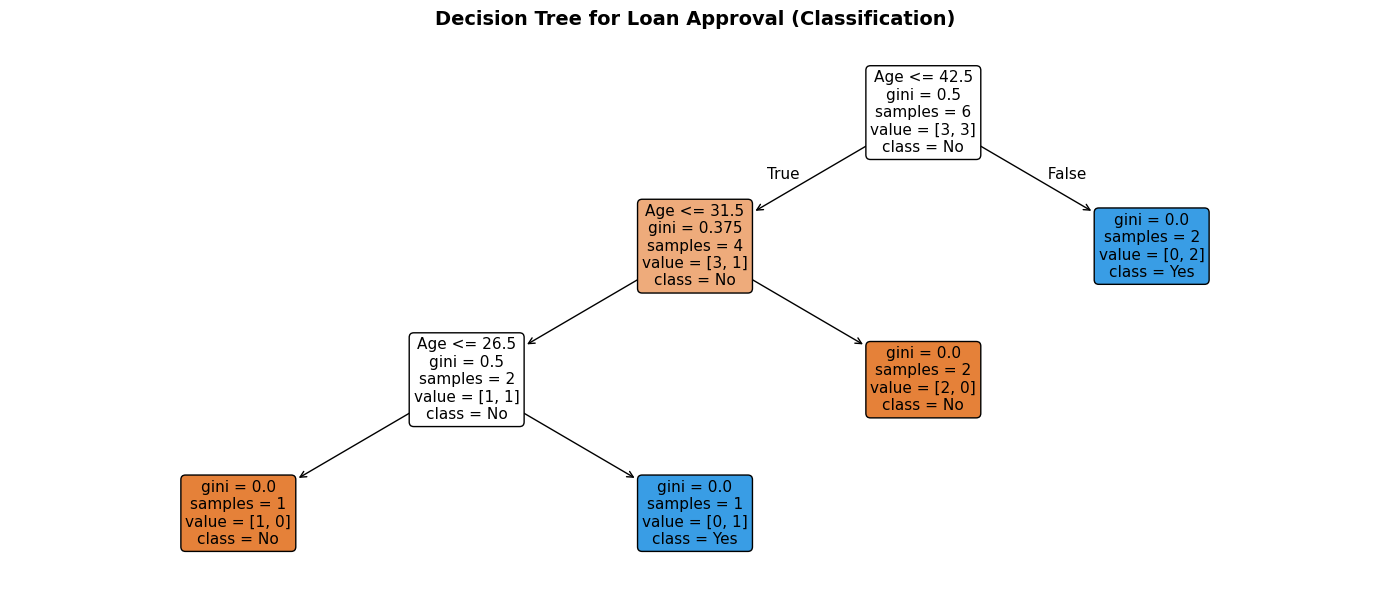

✅ Classification tree plotted!


In [7]:
# Visualize the Classification Tree

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(
    clf,
    feature_names=['Age', 'Employment\n(0=Salaried, 1=Self-Emp)'],
    class_names=le_loan.classes_,
    filled=True,
    rounded=True,
    fontsize=11,
    ax=ax
)
ax.set_title("Decision Tree for Loan Approval (Classification)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('classification_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Classification tree plotted!")

In [8]:
# Text representation of the tree
tree_rules = export_text(clf, feature_names=['Age', 'Employment'])
print("Tree Rules:")
print(tree_rules)

Tree Rules:
|--- Age <= 42.50
|   |--- Age <= 31.50
|   |   |--- Age <= 26.50
|   |   |   |--- class: 0
|   |   |--- Age >  26.50
|   |   |   |--- class: 1
|   |--- Age >  31.50
|   |   |--- class: 0
|--- Age >  42.50
|   |--- class: 1



In [9]:
# Predict a new sample

# Predict for: Age=30, Employment='Salaried'
new_person = pd.DataFrame({'Age': [30], 'Employment_enc': [le_emp.transform(['Salaried'])[0]]})
pred = clf.predict(new_person)
pred_label = le_loan.inverse_transform(pred)[0]
pred_proba = clf.predict_proba(new_person)[0]

print("New Sample → Age=30, Employment='Salaried'")
print(f"  Prediction: Loan = {pred_label}")
print(f"  Probability: No={pred_proba[0]:.2f}, Yes={pred_proba[1]:.2f}")

New Sample → Age=30, Employment='Salaried'
  Prediction: Loan = Yes
  Probability: No=0.00, Yes=1.00


### 4.3 Entropy vs Gini — Comparison

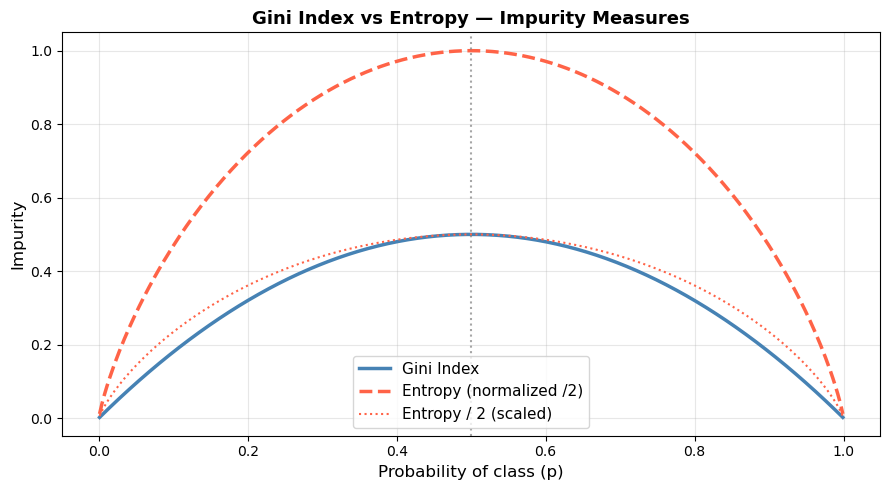

📊 Both peak at p=0.5 (maximum uncertainty/impurity)
📊 Gini: faster to compute | Entropy: more sensitive to class probabilities


In [10]:
# Visualize Gini vs Entropy across probability

p = np.linspace(0.001, 0.999, 300)

gini_vals    = 2 * p * (1 - p)             # Binary Gini = 1 - p^2 - (1-p)^2
entropy_vals = -p * np.log2(p) - (1-p) * np.log2(1-p)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p, gini_vals,    label='Gini Index', linewidth=2.5, color='steelblue')
ax.plot(p, entropy_vals, label='Entropy (normalized /2)', linewidth=2.5, color='tomato',
        linestyle='--')
ax.plot(p, entropy_vals/2, label='Entropy / 2 (scaled)', linewidth=1.5, color='tomato',
        linestyle=':')

ax.set_xlabel('Probability of class (p)', fontsize=12)
ax.set_ylabel('Impurity', fontsize=12)
ax.set_title('Gini Index vs Entropy — Impurity Measures', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Max impurity (p=0.5)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gini_vs_entropy.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Both peak at p=0.5 (maximum uncertainty/impurity)")
print("📊 Gini: faster to compute | Entropy: more sensitive to class probabilities")

---
## Part 5. Decision Tree for Regression <a id='regression'></a>

### The Dataset (House Price Example)

| ID | Size (sqft) | Price ($000s) |
|----|-------------|---------------|
| 1  | 800         | 100           |
| 2  | 900         | 120           |
| 3  | 1100        | 150           |
| 4  | 1300        | 200           |
| 5  | 1500        | 220           |

**Goal:** Predict house price (continuous value).

### Impurity Measure for Regression: MSE

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y})^2$$

- **Step 1:** Start at root → find average price = $\bar{y} = 158$ (without any split)
- **Step 2:** Compute root MSE = 2096 (high impurity!)
- **Step 3:** Try possible splits: 850, 1000, 1200, 1400
- **Step 4:** Compute weighted MSE after each split → pick the best
- **Step 5:** Best split at **size < 1000** → Weighted MSE = **560**

> Huge improvement! From 2096 → 560.

In [11]:
# Regression Dataset

reg_data = {
    'ID': [1, 2, 3, 4, 5],
    'Size': [800, 900, 1100, 1300, 1500],
    'Price': [100, 120, 150, 200, 220]
}
df_reg = pd.DataFrame(reg_data)
print("House Price Dataset:")
print(df_reg.to_string(index=False))

mean_price = df_reg['Price'].mean()
print(f"\nOverall mean price (ȳ) = {mean_price}")

House Price Dataset:
 ID  Size  Price
  1   800    100
  2   900    120
  3  1100    150
  4  1300    200
  5  1500    220

Overall mean price (ȳ) = 158.0


In [12]:
# Manual MSE Calculation at Root Node

y_vals = np.array(df_reg['Price'])
y_mean = y_vals.mean()

root_mse = np.mean((y_vals - y_mean)**2)
print(f"Root MSE (no split, predict ȳ={y_mean} for all): {root_mse:.2f}")
print("→ This is the baseline impurity we want to reduce.")

Root MSE (no split, predict ȳ=158.0 for all): 2096.00
→ This is the baseline impurity we want to reduce.


In [13]:
# Try all possible splits on Size

def weighted_mse(left_y, right_y):
    """Compute weighted MSE after a split."""
    n = len(left_y) + len(right_y)
    mse_l = np.mean((left_y - left_y.mean())**2) if len(left_y) > 0 else 0
    mse_r = np.mean((right_y - right_y.mean())**2) if len(right_y) > 0 else 0
    return (len(left_y)/n) * mse_l + (len(right_y)/n) * mse_r


sizes  = df_reg['Size'].values
prices = df_reg['Price'].values

# Midpoints between consecutive sizes
midpoints = [(sizes[i] + sizes[i+1]) / 2 for i in range(len(sizes)-1)]

print(f"{'Split (size <)':<18} {'Left MSE':>10} {'Right MSE':>10} {'Weighted MSE':>14}")
print("-" * 56)

best_wmse, best_split = float('inf'), None
for mid in midpoints:
    mask  = sizes < mid
    left  = prices[mask]
    right = prices[~mask]
    wmse = weighted_mse(left, right)
    mse_l = np.mean((left - left.mean())**2) if len(left) > 0 else 0
    mse_r = np.mean((right - right.mean())**2) if len(right) > 0 else 0
    marker = "  ← BEST" if wmse < best_wmse else ""
    print(f"  size < {mid:<10.0f} {mse_l:>10.2f} {mse_r:>10.2f} {wmse:>14.2f}{marker}")
    if wmse < best_wmse:
        best_wmse, best_split = wmse, mid

print(f"\n✅ Best split: size < {best_split:.0f}")
print(f"   Root MSE = {root_mse:.2f}  →  After split MSE = {best_wmse:.2f}")
print(f"   Reduction: {root_mse - best_wmse:.2f} ({(1 - best_wmse/root_mse)*100:.1f}% improvement)")

Split (size <)       Left MSE  Right MSE   Weighted MSE
--------------------------------------------------------
  size < 850              0.00    1568.75        1255.00  ← BEST
  size < 1000           100.00     866.67         560.00  ← BEST
  size < 1200           422.22     100.00         293.33  ← BEST
  size < 1400          1418.75       0.00        1135.00

✅ Best split: size < 1200
   Root MSE = 2096.00  →  After split MSE = 293.33
   Reduction: 1802.67 (86.0% improvement)


In [14]:
# sklearn Regression Tree

X_reg = df_reg[['Size']]
y_reg = df_reg['Price']

reg_tree = DecisionTreeRegressor(criterion='squared_error', max_depth=2, random_state=42)
reg_tree.fit(X_reg, y_reg)

print("Regression Tree (max_depth=2) trained!")
print(f"  R² score: {reg_tree.score(X_reg, y_reg):.4f}")

# Predictions
test_sizes = [950, 1400]
for s in test_sizes:
    pred = reg_tree.predict([[s]])[0]
    print(f"  House size={s} sqft → Predicted price = ${pred:.0f}k")

Regression Tree (max_depth=2) trained!
  R² score: 0.9809
  House size=950 sqft → Predicted price = $110k
  House size=1400 sqft → Predicted price = $200k


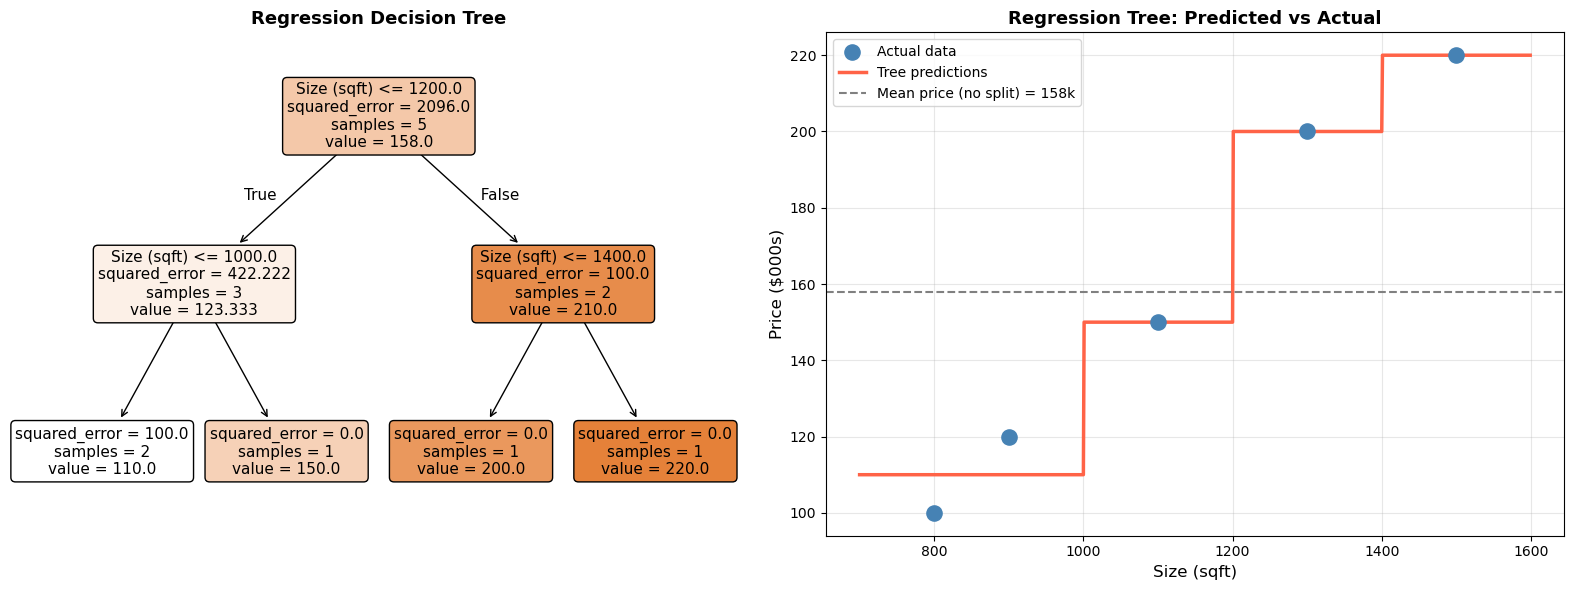

✅ Regression tree plotted!


In [15]:
# Visualize Regression Tree + Predictions

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Tree structure
plot_tree(
    reg_tree,
    feature_names=['Size (sqft)'],
    filled=True, rounded=True, fontsize=11,
    ax=axes[0]
)
axes[0].set_title("Regression Decision Tree", fontsize=13, fontweight='bold')

# Right: Data + step-function predictions
size_range = np.arange(700, 1600, 1).reshape(-1, 1)
price_pred = reg_tree.predict(size_range)

axes[1].scatter(df_reg['Size'], df_reg['Price'], color='steelblue', s=120, zorder=5, label='Actual data')
axes[1].plot(size_range, price_pred, color='tomato', linewidth=2.5, label='Tree predictions')
axes[1].axhline(y_mean, color='gray', linestyle='--', linewidth=1.5, label=f'Mean price (no split) = {y_mean:.0f}k')
axes[1].set_xlabel('Size (sqft)', fontsize=12)
axes[1].set_ylabel('Price ($000s)', fontsize=12)
axes[1].set_title('Regression Tree: Predicted vs Actual', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regression_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Regression tree plotted!")

---
## Part 6. Full sklearn Implementation on Real Dataset <a id='sklearn'></a>

Using the **Iris dataset** for classification and **California Housing** for regression.

In [16]:
# Classification on Iris Dataset

from sklearn.datasets import load_iris

iris = load_iris()
X_iris, y_iris = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

print(f"Iris dataset: {X_iris.shape[0]} samples, {X_iris.shape[1]} features")
print(f"Classes: {iris.target_names}")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Iris dataset: 150 samples, 4 features
Classes: ['setosa' 'versicolor' 'virginica']
Train size: 120, Test size: 30


In [17]:
# Compare Gini vs Entropy criterion
for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"Criterion={criterion:>8} | Depth={model.get_depth()} | Test Accuracy={acc:.4f}")

Criterion=    gini | Depth=5 | Test Accuracy=0.9333
Criterion= entropy | Depth=5 | Test Accuracy=0.9333


Classification Report (Iris - Decision Tree):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



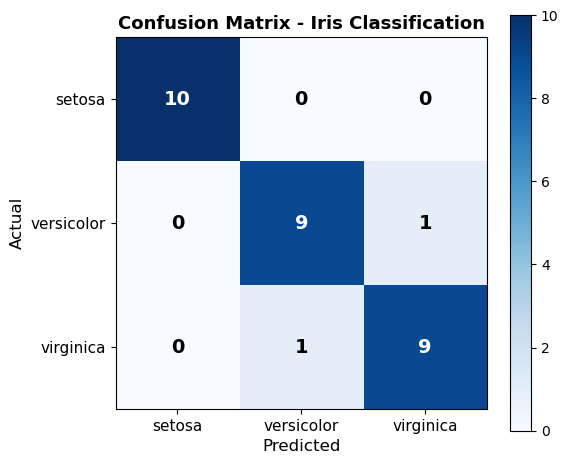

In [18]:
# Final model with Gini
best_clf = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
best_clf.fit(X_train, y_train)
y_pred = best_clf.predict(X_test)

print("Classification Report (Iris - Decision Tree):")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(iris.target_names, fontsize=11)
ax.set_yticklabels(iris.target_names, fontsize=11)
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix - Iris Classification', fontsize=13, fontweight='bold')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7. Overfitting & Hyperparameter Tuning <a id='tuning'></a>

A decision tree **left unconstrained will overfit** — it memorizes the training data but generalizes poorly.

### Key Hyperparameters to Control Overfitting:

| Hyperparameter | Description | Effect of Increasing |
|---|---|---|
| `max_depth` | Max depth of the tree | Reduces overfitting |
| `min_samples_split` | Min samples to split a node | Reduces overfitting |
| `min_samples_leaf` | Min samples in a leaf | Reduces overfitting |
| `max_features` | Max features to consider at each split | Controls variance |
| `max_leaf_nodes` | Max number of leaf nodes | Simplifies tree |

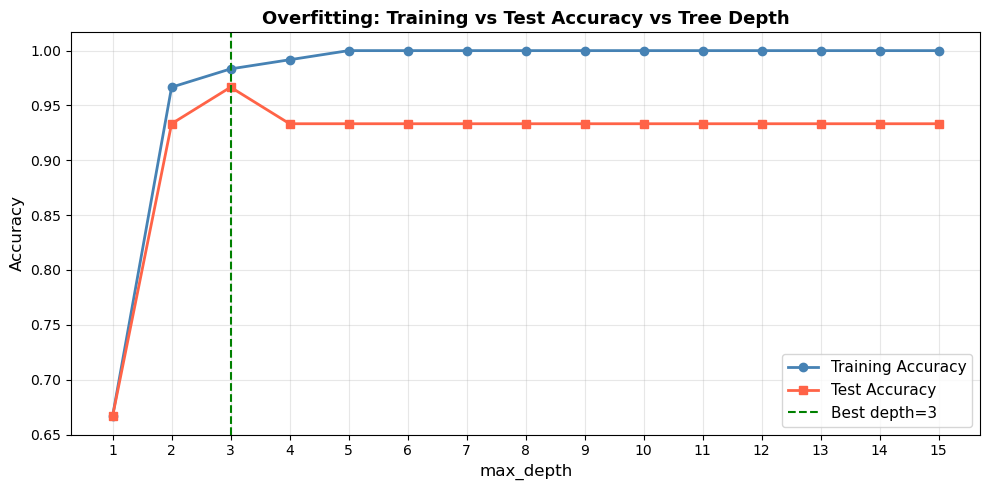

✅ Best test accuracy at max_depth=3: 0.9667
   Notice: training accuracy keeps increasing but test levels off → OVERFITTING


In [19]:
# Effect of max_depth on Train vs Test Accuracy

depths = list(range(1, 16))
train_accs, test_accs = [], []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, model.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  model.predict(X_test)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_accs, 'o-', label='Training Accuracy', color='steelblue', linewidth=2)
ax.plot(depths, test_accs,  's-', label='Test Accuracy',     color='tomato',   linewidth=2)
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Overfitting: Training vs Test Accuracy vs Tree Depth', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(depths)

# Mark the best test accuracy
best_depth = depths[np.argmax(test_accs)]
ax.axvline(best_depth, color='green', linestyle='--', linewidth=1.5,
           label=f'Best depth={best_depth}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('depth_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Best test accuracy at max_depth={best_depth}: {max(test_accs):.4f}")
print("   Notice: training accuracy keeps increasing but test levels off → OVERFITTING")

In [20]:
# Summary: Full Decision Tree Pipeline

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion':        ['gini', 'entropy'],
    'max_depth':        [2, 3, 4, 5, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Grid Search Results:")
print(f"  Best parameters: {grid_search.best_params_}")
print(f"  Best CV accuracy: {grid_search.best_score_:.4f}")
print(f"  Test accuracy with best params: {accuracy_score(y_test, grid_search.best_estimator_.predict(X_test)):.4f}")

Grid Search Results:
  Best parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Best CV accuracy: 0.9417
  Test accuracy with best params: 0.9333


---
## Part 8. Summary

| Topic | Key Points |
|---|---|
| **Why Decision Trees?** | Non-linear, no scaling, interpretable, works for both tasks |
| **Algorithm types** | Single Tree (CART) vs Ensemble (Bagging/Boosting) |
| **Tree structure** | Root → Internal → Leaf nodes |
| **Classification impurity** | Gini (faster) or Entropy (deeper learning) |
| **Regression impurity** | MSE — pick split that reduces it most |
| **Numerical features** | Sort values → try midpoints as split candidates |
| **Root node selection** | Feature with lowest weighted Gini / highest Info Gain |
| **Overfitting** | Control with max_depth, min_samples_split, etc. |
| **Next steps** | Ensemble methods: Random Forest, XGBoost, LightGBM |

---

### 🔑 Key Formulas

$$\text{Gini} = 1 - \sum_{i} p_i^2 \qquad \text{Entropy} = -\sum_{i} p_i \log_2(p_i)$$

$$\text{Information Gain} = \text{Entropy}(\text{parent}) - \sum_{\text{children}} \frac{n_k}{n} \cdot \text{Entropy}(k)$$

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \bar{y})^2 \qquad \text{(Regression impurity)}$$